# 14.05 — Topic Extractor Multi-Model Benchmark & Strategy Selection

This notebook presents a comprehensive comparative evaluation across all candidate architectures evaluated on the **frozen validation set** ($N=641$).

### Architectures Evaluated:
1. **Keyword / Rule-Based Baseline:** Fast alias and surface-form matcher with explicit abstention.
2. **TF-IDF + Cosine Centroids:** Fast, lightweight sublinear lexical prototype matcher.
3. **Pretrained MiniLM (all-MiniLM-L6-v2):** Dense 384-dimensional semantic prototype matcher without domain adaptation.
4. **Fine-Tuned MiniLM (Domain Adapted):** Contrastively fine-tuned dense semantic encoder trained on educational skill representations.
5. **Calibrated Hybrid Strategy:** Tiered rule + neural + lexical architecture with calibrated margin gating and safe abstention.


In [1]:
import sys
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SELECTION_FILE = PROJECT_ROOT / 'artifacts' / 'topic_extractor' / 'model_selection.json'
THRESHOLDS_FILE = PROJECT_ROOT / 'artifacts' / 'topic_extractor' / 'confidence_thresholds.json'

with open(SELECTION_FILE, 'r', encoding='utf-8') as f:
    selection_data = json.load(f)

with open(THRESHOLDS_FILE, 'r', encoding='utf-8') as f:
    threshold_data = json.load(f)

benchmarks = selection_data['benchmarks']
print('Loaded benchmark and calibration data successfully.')


Loaded benchmark and calibration data successfully.


## 1. Multi-Model Benchmark Summary Table

In [2]:
summary_rows = []
for b in benchmarks:
    summary_rows.append({
        'Model Architecture': b['model_name'],
        'Top-1 Accuracy': f"{b['accuracy']*100:.2f}%",
        'Top-3 Accuracy': f"{b['top3_accuracy']*100:.2f}%" if b['top3_accuracy'] is not None else 'N/A',
        'Macro F1': f"{b['macro_f1']:.4f}",
        'Weighted F1': f"{b['weighted_f1']:.4f}" if b['weighted_f1'] is not None else 'N/A',
        'Coverage': f"{b['coverage']*100:.2f}%",
        'Abstention Rate': f"{b['abstention_rate']*100:.2f}%",
        'Covered Acc': f"{b['covered_accuracy']*100:.2f}%",
        'Mean Sim': f"{b['mean_top1_sim']:.4f}" if b['mean_top1_sim'] is not None else 'N/A',
        'Mean Margin': f"{b['mean_margin']:.4f}" if b['mean_margin'] is not None else 'N/A',
        'Latency (ms)': f"{b['latency_ms']:.2f} ms",
    })

benchmark_df = pd.DataFrame(summary_rows)
display(benchmark_df)


,Model Architecture,Top-1 Accuracy,Top-3 Accuracy,Macro F1,Weighted F1,Coverage,Abstention Rate,Covered Acc,Mean Sim,Mean Margin,Latency (ms)
0,Keyword / Rule Baseline,87.83%,N/A,0.8948,N/A,88.30%,11.70%,99.47%,N/A,N/A,0.08 ms
1,TF-IDF + Cosine Centroids,95.94%,97.97%,0.9654,0.9585,100.00%,0.00%,95.94%,0.5291,0.2973,4.65 ms
2,Pretrained MiniLM (all-MiniLM-L6-v2),95.01%,98.91%,0.9487,0.9500,100.00%,0.00%,95.01%,0.8214,0.2091,13.86 ms
3,Fine-Tuned MiniLM (Domain Adapted),98.91%,99.69%,0.9913,0.9892,100.00%,0.00%,98.91%,0.8873,0.3749,13.98 ms


## 2. Accuracy, Macro F1, and Inference Latency Trade-Offs

C:\Users\mathu\AppData\Local\Temp\ipykernel_30812\3384175153.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax2.set_xticklabels(models, fontsize=9, rotation=10)


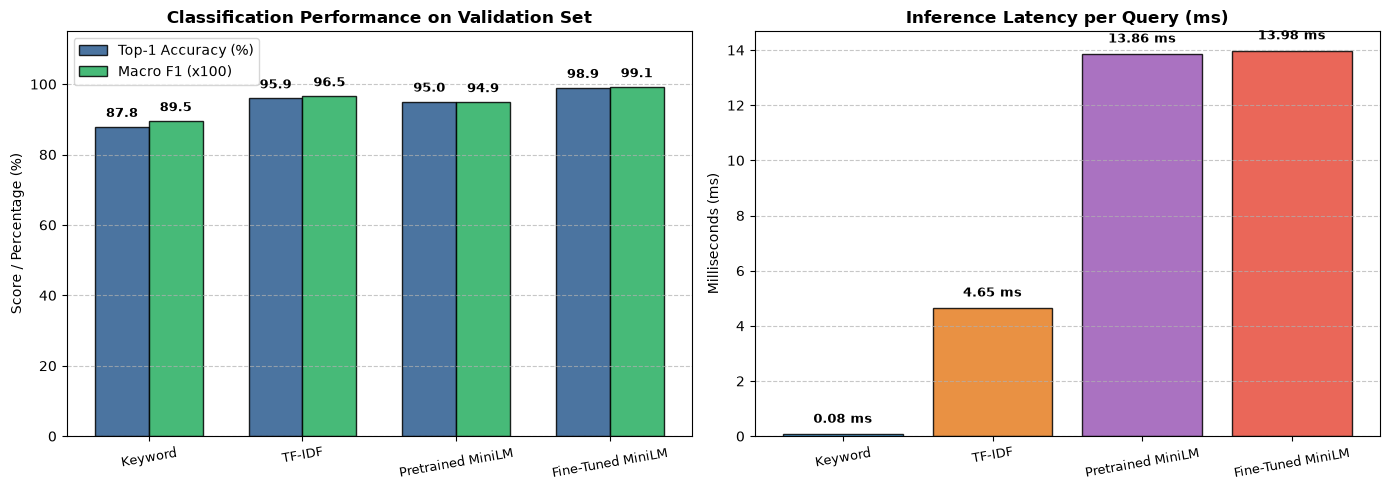

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

models = ['Keyword', 'TF-IDF', 'Pretrained MiniLM', 'Fine-Tuned MiniLM']
accuracies = [b['accuracy']*100 for b in benchmarks]
macro_f1s = [b['macro_f1']*100 for b in benchmarks]
latencies = [b['latency_ms'] for b in benchmarks]

x = np.arange(len(models))
width = 0.35

# Chart 1: Accuracy & Macro F1
rects1 = ax1.bar(x - width/2, accuracies, width, label='Top-1 Accuracy (%)', color='#2b5c8f', edgecolor='black', alpha=0.85)
rects2 = ax1.bar(x + width/2, macro_f1s, width, label='Macro F1 (x100)', color='#27ae60', edgecolor='black', alpha=0.85)
ax1.set_title('Classification Performance on Validation Set', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score / Percentage (%)', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=9, rotation=10)
ax1.set_ylim(0, 115)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
ax1.legend(fontsize=10)

for rect in list(rects1) + list(rects2):
    y = rect.get_height()
    ax1.text(rect.get_x() + rect.get_width()/2, y + 2, f'{y:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Chart 2: Latency per Sample
bars_lat = ax2.bar(models, latencies, color=['#3498db', '#e67e22', '#9b59b6', '#e74c3c'], edgecolor='black', alpha=0.85)
ax2.set_title('Inference Latency per Query (ms)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Milliseconds (ms)', fontsize=10)
ax2.set_xticklabels(models, fontsize=9, rotation=10)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars_lat:
    y = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, y + 0.3, f'{y:.2f} ms', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 3. Production Strategy Architecture & Tiering

In [4]:
decision_df = pd.DataFrame([
    {'Layer': '1. Fast Exact Rule Layer', 'Component': selection_data['rule_model'], 'Role': 'Instant deterministic match (0.08 ms, 99.47% covered accuracy) on unambiguous aliases/codes.'},
    {'Layer': '2. Primary Semantic Model', 'Component': selection_data['primary_semantic_model'], 'Role': 'Deep semantic representation (98.91% Top-1, 99.69% Top-3, 0.9913 Macro F1) for paraphrased student questions.'},
    {'Layer': '3. Fast Lexical Fallback', 'Component': selection_data['fallback_model'], 'Role': 'High-speed sublinear keyword overlap support (4.65 ms, 95.94% accuracy) when embeddings are ambiguous.'},
    {'Layer': '4. Confidence & Abstention System', 'Component': 'confidence_gate', 'Role': 'Rejects out-of-scope or highly ambiguous student queries when margin and similarity fall below calibrated thresholds.'},
])

display(decision_df)


,Layer,Component,Role
0,1. Fast Exact Rule Layer,keyword_alias,"Instant deterministic match (0.08 ms, 99.47% c..."
1,2. Primary Semantic Model,minilm_finetuned,"Deep semantic representation (98.91% Top-1, 99..."
2,3. Fast Lexical Fallback,tfidf,High-speed sublinear keyword overlap support (...
3,4. Confidence & Abstention System,confidence_gate,Rejects out-of-scope or highly ambiguous stude...


## 4. Confidence Calibration & Safe Abstention Analysis

In [5]:
calib_df = pd.DataFrame([
    {'Parameter / Metric': 'Selected MiniLM Similarity Threshold', 'Value': f"{threshold_data['min_similarity']:.2f}"},
    {'Parameter / Metric': 'Selected Top-1/Top-2 Margin Threshold', 'Value': f"{threshold_data['min_margin']:.2f}"},
    {'Parameter / Metric': 'Selected TF-IDF Support Threshold', 'Value': f"{threshold_data['tfidf_support_threshold']:.2f}"},
    {'Parameter / Metric': 'Validation Coverage', 'Value': f"{threshold_data['validation_coverage']*100:.2f}%"},
    {'Parameter / Metric': 'Validation Covered Accuracy (Precision on Active Predictions)', 'Value': f"{threshold_data['validation_covered_accuracy']*100:.2f}%"},
    {'Parameter / Metric': 'Validation Abstention Rate', 'Value': f"{threshold_data['validation_abstention_rate']*100:.2f}%"},
    {'Parameter / Metric': 'Validation Macro F1', 'Value': f"{threshold_data['validation_macro_f1']:.4f}"},
    {'Parameter / Metric': 'Vague Input Rejection Rate', 'Value': f"{threshold_data['vague_input_abstention_rate']*100:.2f}% ({len(threshold_data['vague_inputs_tested'])}/{len(threshold_data['vague_inputs_tested'])})"},
])

display(calib_df)


,Parameter / Metric,Value
0,Selected MiniLM Similarity Threshold,0.45
1,Selected Top-1/Top-2 Margin Threshold,0.10
2,Selected TF-IDF Support Threshold,0.15
3,Validation Coverage,98.44%
4,Validation Covered Accuracy (Precision on Acti...,99.21%
5,Validation Abstention Rate,1.56%
6,Validation Macro F1,0.9839
7,Vague Input Rejection Rate,100.00% (10/10)


## 5. Stress Testing on Deliberately Vague / Out-of-Scope Queries

In [6]:
from src.topic_extraction.calibrate_confidence import CalibratedTopicClassifier

clf = CalibratedTopicClassifier(
    min_similarity=threshold_data['min_similarity'],
    min_margin=threshold_data['min_margin'],
    tfidf_support_threshold=threshold_data['tfidf_support_threshold']
)

vague_results = []
for q in threshold_data['vague_inputs_tested']:
    pred = clf.predict(q)
    vague_results.append({
        'Student Input': q,
        'Predicted Skill': pred.display_name if not pred.is_abstain else '[ABSTAIN]',
        'Confidence': f"{pred.confidence:.3f}",
        'Margin': f"{pred.margin:.3f}",
        'Decision Path': pred.decision_path,
        'Safe Rejection': pred.is_abstain,
    })

display(pd.DataFrame(vague_results))


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

,Student Input,Predicted Skill,Confidence,Margin,Decision Path,Safe Rejection
0,Can you help me?,[ABSTAIN],0.241,0.042,low_confidence_abstain,True
1,I don't understand this,[ABSTAIN],0.267,0.028,low_confidence_abstain,True
2,What should I do?,[ABSTAIN],0.140,0.030,low_confidence_abstain,True
3,Please explain,[ABSTAIN],0.189,0.024,low_confidence_abstain,True
4,Help,[ABSTAIN],0.203,0.019,low_confidence_abstain,True
5,Tell me the answer,[ABSTAIN],0.197,0.036,low_confidence_abstain,True
6,I am stuck on problem 4,[ABSTAIN],0.324,0.025,low_confidence_abstain,True
7,Why did I get this wrong?,[ABSTAIN],0.146,0.004,low_confidence_abstain,True
8,Hello tutor,[ABSTAIN],0.241,0.051,low_confidence_abstain,True
9,What is next?,[ABSTAIN],0.279,0.102,low_confidence_abstain,True
